# Processing LiDAR data from General Seperation Area (GSA)

In [ ]:
# imports

import sys 
import gdown 
import whitebox 
import whitebox_workflows as wbw
from whitebox_workflows import WbEnvironment, show
import geemap 
import rioxarray as rxr
import rasterio 
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd 
from rasterio.plot import plotting_extent


In [ ]:
# instantiating whitebox tools 
wbt = whitebox.WhiteboxTools()

In [ ]:
from pathlib import Path

# Use project root even when notebook runs from /notebooks
base = Path.cwd()
if base.name == "notebooks":
    base = base.parent

data = base / "data" / "GSA_merged.laz"
outputs = base / "outputs" / "lidar_processing" / "gsa_lidar" / "GSA_laz_info"

# Create folders if they don't exist
data.parent.mkdir(parents=True, exist_ok=True)
outputs.parent.mkdir(parents=True, exist_ok=True)

# If missing, download from Google Drive
if not data.exists():
    file_id = "1E8Jnuce6f9myRpzfmJoAnpzL5TdiGZFI"
    gdown.download(f"https://drive.google.com/uc?id={file_id}", str(data), quiet=False)


In [ ]:
# Create info file that displays different parameters such as point return analysis, point return, etc. 
wbt.lidar_info(
    i=str(data),
    output=str(outputs)
)

In [ ]:
# Plotting elevation values of the GSA .laz file

elevation_val_output = base / "outputs" / "lidar_processing" / "gsa_lidar" / "GSA_elev_hist.html"

wbt.lidar_histogram(
    i = str(data),
    output = str(elevation_val_output),
    parameter = "elevation",
    clip = 0
)

In [ ]:
# Plotting histogram of the classes within GSA .laz file 

class_hist_output = base / "outputs" / "lidar_processing" / "gsa_lidar" / "GSA_class_hist.html"

wbt.lidar_histogram(
    i = str(data), 
    output = str(class_hist_output),
    parameter = "class", 
    clip = 0
)

.\whitebox_tools.exe --run="LidarGroundPointFilter" --input='c:\Users\arcmod_guest\Desktop\tomasm\lidar-workflows\data\GSA_merged.laz' --output='c:\Users\arcmod_guest\Desktop\tomasm\lidar-workflows\data\GSA_ground.laz' --radius=2.0 --min_neighbours=0 --slope_threshold=45.0 --height_threshold=1.0 --classify --slope_norm -v --compress_rasters=False

*************************************
* Welcome to LidarGroundPointFilter *
* Powered by WhiteboxTools          *
* www.whiteboxgeo.com               *
*************************************
reading input LiDAR file...
Performing analysis...
Binning points: 0%
Binning points: 1%
Binning points: 2%
Binning points: 3%
Binning points: 4%
Binning points: 5%
Binning points: 6%
Binning points: 7%
Binning points: 8%
Binning points: 9%
Binning points: 10%
Binning points: 11%
Binning points: 12%
Binning points: 13%
Binning points: 14%
Binning points: 15%
Binning points: 16%
Binning points: 17%
Binning points: 18%
Binning points: 19%
Binning points: 20%

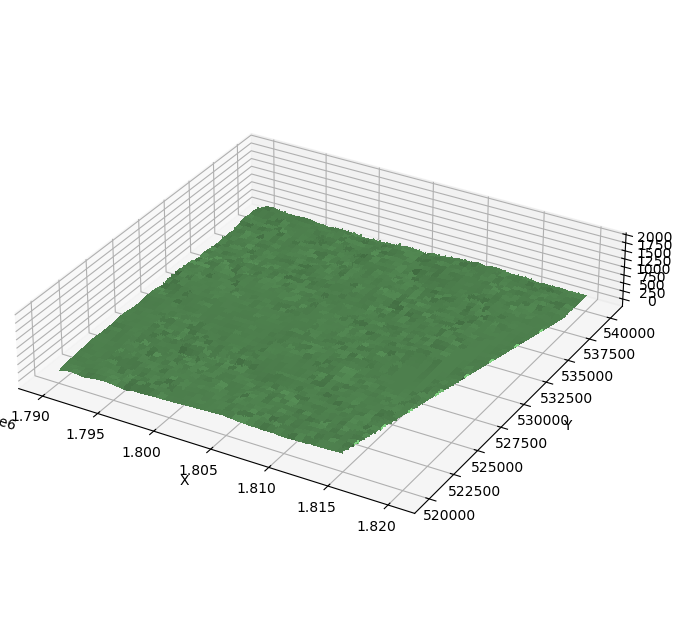

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

In [53]:
# Creating 3D Interactive Surface Plot from Raster DEMs
from whitebox_workflows import WbEnvironment, show

wbe = WbEnvironment()

wbe.working_directory = str(base / "data") 

# Step 1 - Ground classify the point cloud 
wbt.lidar_ground_point_filter(
    i = str(data), 
    output = str(base / "data" / "GSA_ground.laz"),
)

# Step 2 - convert to raster DEM 
wbt.lidar_tin_gridding (
    i = str(base / "data" / "GSA_ground.laz"),
    output = str(base / "data" / "GSA_dem.tif"), 
    resolution = 1.0
)



dem = wbe.read_raster('GSA_dem.tif')

show(
    dem, 
    figsize = (10, 8),
    skip = 2,
    plot_as_surface = True,
    vert_exaggeration = 2.5,
    color = 'lightgreen',
    shade = True,
    linewidth = 0.0,
    rcount = 50,
    ccount = 50,
    antialiased = False
)



In [ ]:
# Performing hydrological analysis on the DEM 

import math 

